# 03 — Embeddings + Clustering para detección de roles

Genera embeddings de mensajes con `qwen3-embedding` (4096 dims),  
reduce a 2D con UMAP y agrupa actores con HDBSCAN.  
Contrasta los clusters con los roles inferidos por LLM en el notebook 02.

Produce:
- `data/processed/message_embeddings.npy` — matriz (N, 4096)
- `data/processed/actor_embeddings.parquet` — centroide por actor + cluster + rol
- `data/processed/conti_sample_with_embeddings.parquet` — muestra + cluster por mensaje

## 0. Setup

In [15]:
# sys para modificar el path de Python y poder importar módulos locales de src/.
import sys
from pathlib import Path

# Añadimos la carpeta src/ al path de Python para acceder a nuestros loaders.
sys.path.insert(0, str(Path('src').resolve()))

# json para leer el archivo de perfiles de actores generado por el notebook 02.
import json

# numpy es la librería de Python para trabajar con matrices y arrays numéricos.
# Los "embeddings" son vectores de números (arrays), así que numpy es esencial aquí.
import numpy as np

# pandas para cargar y manipular tablas de datos.
import pandas as pd

# ollama para interactuar con el modelo de embeddings local.
import ollama

# umap es una librería para reducir dimensionalidad: convierte vectores de 4096 dimensiones
# en vectores de 2 dimensiones para poder visualizarlos en un gráfico 2D.
# UMAP = Uniform Manifold Approximation and Projection.
import umap

# hdbscan es un algoritmo de clustering (agrupación) que detecta grupos de actores
# similares sin necesidad de especificar cuántos grupos queremos de antemano.
# HDBSCAN = Hierarchical Density-Based Spatial Clustering of Applications with Noise.
import hdbscan

# matplotlib para crear gráficos y visualizaciones.
import matplotlib.pyplot as plt
import matplotlib.cm as cm  # cm = color maps (paletas de colores predefinidas)

# tqdm para barras de progreso durante la generación de embeddings (proceso lento).
from tqdm.auto import tqdm

# --- Rutas de archivos ---
PROCESSED_DIR = Path('../data_Vruto/ContiLeaks')

# Archivo de entrada: la muestra de mensajes clasificados por el notebook 02.
SAMPLE_IN       = PROCESSED_DIR / 'conti_sample_classified.parquet'

# Archivo de entrada: los perfiles de actores inferidos por el LLM en el notebook 02.
PROFILES_IN     = PROCESSED_DIR / 'actor_profiles.json'

# Archivo de salida (y caché): la matriz de embeddings de todos los mensajes.
# Guardamos en .npy (formato binario de numpy) porque es muy rápido de cargar.
EMBEDDINGS_NPY  = PROCESSED_DIR / 'message_embeddings.npy'

# Archivos de salida con los embeddings reducidos y los clusters de actores.
ACTOR_EMB_OUT   = PROCESSED_DIR / 'actor_embeddings.parquet'
SAMPLE_OUT      = PROCESSED_DIR / 'conti_sample_with_embeddings.parquet'

# El modelo de embeddings. qwen3-embedding convierte texto en vectores de 4096 números.
# Un embedding captura el "significado" del texto de forma que textos similares
# tengan vectores cercanos en el espacio matemático.
EMBED_MODEL = 'qwen3-embedding'
EMBED_DIMS  = 4096  # Número de dimensiones de cada vector de embedding

# Número de mensajes que enviamos al modelo en cada llamada.
# Enviar varios a la vez es más eficiente que enviarlos uno a uno.
BATCH_SIZE  = 32  # mensajes por llamada a ollama.embed()

# Verificamos que los archivos de entrada del notebook 02 existen.
for p in [SAMPLE_IN, PROFILES_IN]:
    assert p.exists(), f'No se encuentra {p} — ejecuta primero el notebook 02'

print('Dependencias OK')

Dependencias OK


## 1. Cargar datos de notebook 02

In [16]:
# Cargamos la muestra de mensajes clasificados del notebook 02.
sample = pd.read_parquet(SAMPLE_IN)

# Cargamos los perfiles de actores (diccionario con rol, confianza, resumen, evidencia).
# json.load() lee el archivo JSON y lo convierte en un diccionario Python.
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

# Mostramos un resumen para verificar que los datos se cargaron correctamente.
print(f'Mensajes en muestra : {len(sample):,}')
print(f'Actores             : {sample.username.nunique()}')
print(f'Perfiles de actores : {len(profiles)}')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

Mensajes en muestra : 2,520
Actores             : 30
Perfiles de actores : 30

Categorías:
category
technical         903
comms             838
unknown           375
operational       256
financial          89
organizational     59


## 2. Generar embeddings de mensajes

`ollama.embed()` acepta listas de textos → procesamos en batches para eficiencia.  
Si ya existe el `.npy`, lo cargamos directamente.

In [17]:
# Generamos los embeddings de todos los mensajes de la muestra.
# Un embedding es un vector de números que representa el "significado" de un texto
# de manera que textos similares tienen vectores matemáticamente cercanos.
# Generar 1500 embeddings con un modelo de 4096 dimensiones tarda varios minutos,
# por eso guardamos el resultado en un archivo .npy para no tener que repetirlo.

if EMBEDDINGS_NPY.exists():
    # Si ya calculamos los embeddings antes, los cargamos desde el archivo guardado.
    # np.load() carga un archivo .npy como un array de numpy.
    embeddings = np.load(EMBEDDINGS_NPY)

    # Verificamos que el número de embeddings coincide con el número de mensajes.
    # Si no coincide, puede que la muestra cambió desde que se generaron los embeddings.
    assert len(embeddings) == len(sample), 'Tamaño de embeddings no coincide con la muestra'
    print(f'Embeddings cargados desde caché: {embeddings.shape}')
else:
    # Si no existe el caché, generamos los embeddings desde cero.
    # Preparamos la lista de textos a embedir (eliminando espacios extra con .strip()).
    texts = sample['message'].str.strip().tolist()

    # Creamos una matriz de ceros del tamaño correcto: (num_mensajes, num_dimensiones).
    # dtype=np.float32 usa 32 bits por número (menos memoria que float64) sin perder precisión relevante.
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    # Procesamos los textos en lotes (batches) de BATCH_SIZE mensajes.
    # range(0, len(texts), BATCH_SIZE) genera los índices de inicio de cada lote: 0, 32, 64, 96...
    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Generando embeddings'):
        # Tomamos un lote de mensajes: desde 'start' hasta 'start + BATCH_SIZE'.
        batch = texts[start:start + BATCH_SIZE]

        # Llamamos al modelo de embeddings con el lote completo.
        # ollama.embed() devuelve un objeto con la lista de vectores en resp.embeddings.
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)

        # Guardamos cada embedding en la fila correspondiente de la matriz.
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    # Guardamos la matriz completa en un archivo .npy para no tener que regenerarla.
    # np.save() guarda el array en formato binario de numpy (rápido y compacto).
    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Embeddings guardados → {EMBEDDINGS_NPY}  {embeddings.shape}')

Embeddings cargados desde caché: (2520, 4096)


## 3. Centroides por actor

Cada actor queda representado por la media de los embeddings de sus mensajes.

In [18]:
# Calculamos el "centroide" de cada actor: el vector promedio de todos sus mensajes.
# Imagina que cada mensaje es un punto en un espacio de 4096 dimensiones.
# El centroide de un actor es el punto central de todos sus mensajes.
# Actores con estilos de comunicación similares tendrán centroides cercanos.

# Hacemos una copia de la muestra y añadimos una columna con la posición de cada mensaje
# en la matriz de embeddings (para poder recuperar su vector).
sample_emb = sample.copy()
sample_emb['emb_idx'] = range(len(sample_emb))  # índice de 0 a 1499

# Diccionario donde guardaremos el vector centroide de cada actor.
actor_centroids = {}

# Agrupamos los mensajes por actor y calculamos el promedio de sus embeddings.
for actor, group in sample_emb.groupby('username'):
    # Obtenemos los índices de los mensajes de este actor.
    idxs = group['emb_idx'].tolist()

    # embeddings[idxs] selecciona las filas correspondientes de la matriz de embeddings.
    # .mean(axis=0) calcula el promedio a lo largo del eje de las filas
    # (es decir, para cada una de las 4096 dimensiones, calcula el valor medio).
    actor_centroids[actor] = embeddings[idxs].mean(axis=0)

# Convertimos el diccionario en una matriz numpy para poder aplicar UMAP y HDBSCAN.
# El orden de los actores se preserva en actor_names.
actor_matrix = np.array([actor_centroids[a] for a in actor_centroids])
actor_names  = list(actor_centroids.keys())

print(f'Centroides calculados: {actor_matrix.shape}  ({len(actor_names)} actores)')

Centroides calculados: (30, 4096)  (30 actores)


## 4. UMAP — reducción a 2D

Reducimos tanto los mensajes como los centroides de actores al mismo espacio 2D.

In [19]:
# Aplicamos UMAP para reducir los embeddings de 4096 dimensiones a 2 dimensiones.
# Esto nos permite visualizar en un gráfico 2D la similitud entre mensajes y actores.
# UMAP intenta preservar las distancias relativas: puntos cercanos en 4096D
# siguen siendo cercanos en 2D.

# Creamos el reductor UMAP con sus parámetros:
reducer = umap.UMAP(
    n_components=2,    # Reducir a 2 dimensiones (para visualizar en un plano)
    n_neighbors=15,    # Cuántos vecinos cercanos considera para construir el grafo local.
                       # Valores más pequeños → estructura local más detallada.
                       # Valores más grandes → estructura global más preservada.
    min_dist=0.1,      # Distancia mínima permitida entre puntos en el espacio 2D.
                       # Valores pequeños → puntos más agrupados.
    metric='cosine',   # Usa similitud coseno para medir distancias entre embeddings.
                       # La similitud coseno es mejor que la distancia euclidiana para texto.
    random_state=42    # Semilla aleatoria para que los resultados sean reproducibles.
)

# fit_transform() aprende la proyección 2D a partir de los embeddings de mensajes
# y luego aplica la proyección. Devuelve las coordenadas 2D de cada mensaje.
print('Ajustando UMAP sobre mensajes...')
msg_2d = reducer.fit_transform(embeddings)

# transform() aplica la proyección ya aprendida a los centroides de actores.
# Así los actores quedan en el mismo espacio 2D que los mensajes.
print('Proyectando centroides de actores...')
actor_2d = reducer.transform(actor_matrix)

# Mostramos las formas de las matrices resultantes para verificar.
print(f'Mensajes en 2D  : {msg_2d.shape}')   # Debería ser (1500, 2)
print(f'Actores en 2D   : {actor_2d.shape}')  # Debería ser (30, 2)

Ajustando UMAP sobre mensajes...


/home/drjekyll/FearOfTheDark/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Proyectando centroides de actores...
Mensajes en 2D  : (2520, 2)
Actores en 2D   : (30, 2)


## 5. HDBSCAN — clustering de actores

Agrupa actores por similitud en el espacio de embeddings (no por volumen de mensajes).  
Cluster `-1` = ruido (actores sin grupo claro).

In [20]:
# Aplicamos HDBSCAN para agrupar los actores en clusters basándonos en sus
# coordenadas UMAP. HDBSCAN encuentra grupos de puntos densos automáticamente,
# sin necesitar que le digamos cuántos grupos queremos.

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=3,  # Un cluster necesita al menos 3 actores para formarse.
                         # Si hay menos de 3 actores similares, se clasifican como "ruido".
    min_samples=2,       # Cuántos vecinos necesita un punto para ser considerado "núcleo"
                         # de un cluster (en vez de punto periférico o ruido).
    metric='euclidean'   # Usamos distancia euclidiana en el espacio 2D de UMAP.
)

# fit_predict() ajusta el modelo y devuelve el cluster asignado a cada actor.
# El valor -1 indica "ruido": actores que no encajan bien en ningún cluster.
actor_clusters = clusterer.fit_predict(actor_2d)

# Calculamos estadísticas de los clusters.
# set() elimina duplicados para obtener los valores únicos.
# "- (1 if -1 in actor_clusters else 0)" descuenta el -1 del conteo de clusters reales.
n_clusters = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise    = (actor_clusters == -1).sum()  # Cuántos actores quedaron sin cluster

print(f'Clusters encontrados : {n_clusters}')
print(f'Actores sin cluster  : {n_noise}')
print()

# Mostramos qué actores pertenecen a cada cluster.
for cl in sorted(set(actor_clusters)):
    # Construimos la lista de nombres de actores de este cluster.
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    print(f'  {label:<12}: {members}')

Clusters encontrados : 3
Actores sin cluster  : 1

  ruido       : ['marsel']
  cluster 0   : ['defender', 'driver', 'hof', 'veron']
  cluster 1   : ['angelo', 'braun', 'deploy', 'mango', 'mors', 'stern', 'tramp']
  cluster 2   : ['baget', 'bentley', 'bio', 'bloodrush', 'kaktus', 'mushroom', 'price', 'professor', 'revers', 'strix', 'target', 'tl1', 'tl2', 'ttrr', 'user4', 'user7', 'user8', 'user9']


## 6. Visualizaciones

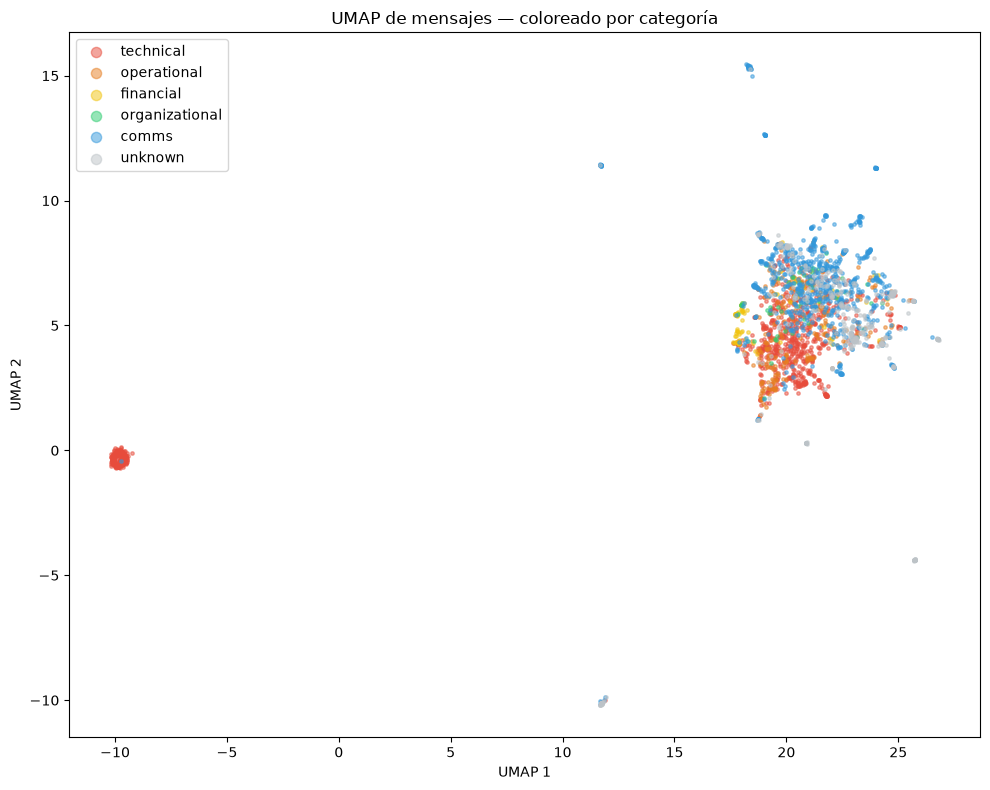

In [21]:
# --- Gráfico de dispersión (scatter plot) de mensajes coloreados por categoría ---
# Cada punto representa un mensaje. Su posición viene determinada por las
# coordenadas 2D que calculó UMAP. El color indica la categoría del mensaje.
# Si el modelo de embeddings funciona bien, veremos que los puntos del mismo
# color tienden a agruparse en regiones del gráfico.

# Definimos el color de cada categoría manualmente para que sea intuitivo:
# rojo → técnico, naranja → operacional, amarillo → financiero, etc.
cat_color = {
    'technical':      '#e74c3c',   # Rojo
    'operational':    '#e67e22',   # Naranja
    'financial':      '#f1c40f',   # Amarillo
    'organizational': '#2ecc71',   # Verde
    'comms':          '#3498db',   # Azul
    'unknown':        '#bdc3c7',   # Gris
}

fig, ax = plt.subplots(figsize=(10, 8))

# Dibujamos una capa de puntos por cada categoría para poder controlar
# el color y la etiqueta de la leyenda independientemente.
for cat, color in cat_color.items():
    # Creamos una máscara booleana: True para los mensajes de esta categoría.
    mask = sample['category'] == cat

    # msg_2d[mask, 0] son las coordenadas X de los mensajes de esta categoría.
    # msg_2d[mask, 1] son las coordenadas Y.
    # s=6 → puntos pequeños para que no se solapen demasiado.
    # alpha=0.5 → 50% de transparencia para ver la densidad de puntos.
    # rasterized=True → convierte los puntos a imagen rasterizada (más rápido de renderizar).
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=6, alpha=0.5, label=cat, rasterized=True)

ax.set_title('UMAP de mensajes — coloreado por categoría')
ax.legend(markerscale=3, framealpha=0.8)  # markerscale=3 hace los puntos de la leyenda más grandes
ax.set_xlabel('UMAP 1')   # Eje horizontal: primera componente UMAP
ax.set_ylabel('UMAP 2')   # Eje vertical: segunda componente UMAP
plt.tight_layout()
plt.show()

/tmp/ipykernel_21959/1405120646.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


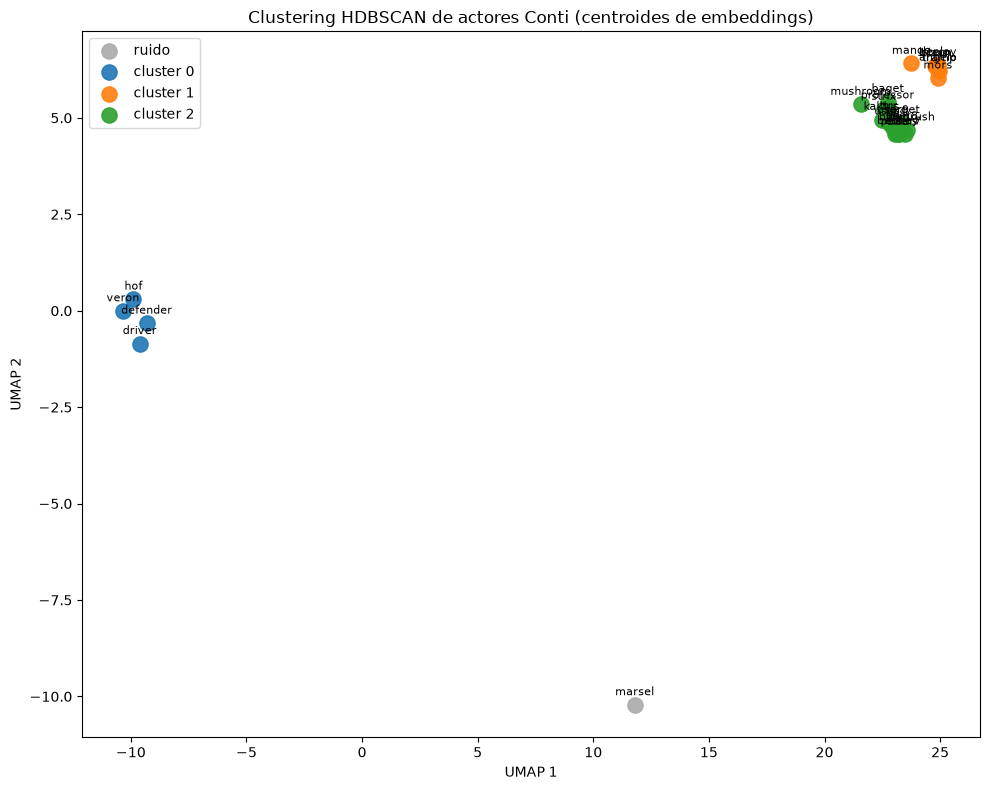

In [22]:
# --- Gráfico de actores coloreados por cluster HDBSCAN ---
# Cada punto representa un actor (el centroide de sus mensajes en 2D).
# El color indica a qué cluster HDBSCAN lo asignó.

# Obtenemos los valores únicos de clusters (pueden ser -1, 0, 1, 2, ...).
unique_clusters = sorted(set(actor_clusters))

# Paleta de colores: tab10 tiene 10 colores distintos claramente diferenciados.
palette = cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 8))

# Dibujamos un grupo de puntos por cada cluster.
for cl in unique_clusters:
    # Máscara booleana para los actores de este cluster.
    mask  = actor_clusters == cl

    # Los actores de "ruido" (cl == -1) se dibujan en gris.
    # Los demás se dibujan con un color de la paleta.
    color = '#aaaaaa' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'

    # Dibujamos puntos más grandes que en el gráfico de mensajes (s=120) porque
    # tenemos solo 30 actores y necesitamos que sean visibles con etiquetas.
    # zorder=3 asegura que los puntos se dibujen encima de cualquier otro elemento.
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=120, alpha=0.9, label=label, zorder=3)

# Añadimos el nombre de cada actor como etiqueta junto a su punto.
for i, name in enumerate(actor_names):
    # ax.annotate añade texto junto a un punto del gráfico.
    # xytext=(0, 5) desplaza el texto 5 puntos hacia arriba del punto.
    # textcoords='offset points' indica que el desplazamiento es en puntos tipográficos.
    ax.annotate(name, (actor_2d[i, 0], actor_2d[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_title('Clustering HDBSCAN de actores Conti (centroides de embeddings)')
ax.legend()
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

In [23]:
# Construimos un DataFrame que combina el cluster HDBSCAN de cada actor
# con el rol inferido por el LLM en el notebook 02.
# Esto nos permite comparar ambos análisis: ¿coinciden los grupos matemáticos
# con los roles inferidos lingüísticamente?

actor_df = pd.DataFrame({
    'actor':   actor_names,           # Nombre de usuario del actor
    'cluster': actor_clusters,        # Cluster asignado por HDBSCAN (-1 = ruido)
    'umap_x':  actor_2d[:, 0],        # Coordenada X en el espacio 2D de UMAP
    'umap_y':  actor_2d[:, 1],        # Coordenada Y en el espacio 2D de UMAP
})

# Añadimos el rol y la confianza inferidos por el LLM, leyendo del diccionario de perfiles.
# .map(lambda ...) aplica una función a cada valor de la columna 'actor'.
# profiles.get(a, {}) devuelve el perfil del actor 'a', o un diccionario vacío si no existe.
# .get('role', 'unknown') devuelve el rol, o 'unknown' si el perfil no tiene ese campo.
actor_df['llm_role'] = actor_df['actor'].map(
    lambda a: profiles.get(a, {}).get('role', 'unknown')
)
actor_df['llm_confidence'] = actor_df['actor'].map(
    lambda a: profiles.get(a, {}).get('confidence', 'low')
)

# Mostramos la tabla completa ordenada por cluster y luego por rol del LLM.
# Esto facilita ver si los clusters agrupan actores con roles similares.
print('=== ACTORES: cluster HDBSCAN vs rol LLM ===')
print(actor_df[['actor', 'cluster', 'llm_role', 'llm_confidence']]
      .sort_values(['cluster', 'llm_role'])
      .to_string(index=False))

=== ACTORES: cluster HDBSCAN vs rol LLM ===
    actor  cluster  llm_role llm_confidence
   marsel       -1  operator           high
   driver        0  operator         medium
      hof        0  operator         medium
    veron        0  operator         medium
 defender        0   support           high
    braun        1 developer           high
   deploy        1  operator           high
    mango        1  operator         medium
     mors        1  operator           high
    stern        1  operator         medium
    tramp        1  operator         medium
   angelo        1   unknown            low
   kaktus        2 developer           high
 mushroom        2 developer           high
    price        2 developer         medium
professor        2 developer           high
     ttrr        2 developer           high
    baget        2  operator         medium
  bentley        2  operator         medium
bloodrush        2  operator         medium
   revers        2  operator    

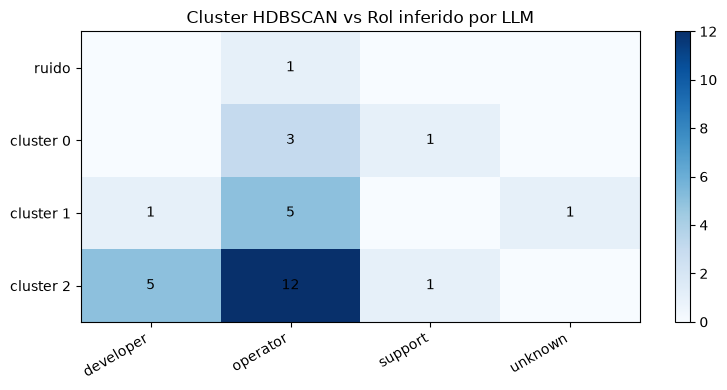

In [24]:
# Creamos un heatmap de "tabla cruzada" (crosstab) entre cluster HDBSCAN y rol LLM.
# Esto muestra cuántos actores tienen cada combinación de (cluster, rol).
# Si los clusters coinciden bien con los roles, cada fila debería tener un
# color dominante en una sola columna.

# pd.crosstab crea una tabla de contingencia: filas = clusters, columnas = roles,
# valores = número de actores con esa combinación.
cross = pd.crosstab(actor_df['cluster'], actor_df['llm_role'])

fig, ax = plt.subplots(figsize=(8, 4))

# imshow muestra la tabla como un mapa de calor con la paleta azul (Blues).
# Valores más altos = color más oscuro.
im = ax.imshow(cross.values, aspect='auto', cmap='Blues')

# Configuramos las etiquetas del eje X (roles del LLM).
ax.set_xticks(range(len(cross.columns)))
ax.set_xticklabels(cross.columns, rotation=30, ha='right')

# Configuramos las etiquetas del eje Y (clusters HDBSCAN).
# Los índices negativos (-1) son el grupo de ruido.
ax.set_yticks(range(len(cross.index)))
ax.set_yticklabels([f'cluster {i}' if i >= 0 else 'ruido' for i in cross.index])

ax.set_title('Cluster HDBSCAN vs Rol inferido por LLM')

# Añadimos la barra de colores para interpretar la escala.
plt.colorbar(im, ax=ax)

# Añadimos el número exacto dentro de cada celda del heatmap para facilitar la lectura.
for i in range(len(cross.index)):
    for j in range(len(cross.columns)):
        v = cross.values[i, j]
        # Solo mostramos el número si es mayor que 0 (no ensuciamos con ceros).
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Actores más similares entre sí (similitud coseno)

Para cada actor, los 3 más cercanos en el espacio de embeddings.

In [25]:
# Calculamos la similitud coseno entre todos los pares de actores.
# La similitud coseno mide el ángulo entre dos vectores: 1 = idénticos, 0 = perpendiculares, -1 = opuestos.
# Para embeddings de texto, valores > 0.9 indican estilos de comunicación muy similares.
from sklearn.metrics.pairwise import cosine_similarity

# cosine_similarity() recibe una matriz (actores × dimensiones) y devuelve una matriz
# cuadrada (actores × actores) donde el valor [i][j] es la similitud entre los actores i y j.
sim_matrix = cosine_similarity(actor_matrix)

# Ponemos -1 en la diagonal (similitud de cada actor consigo mismo) para que no aparezca
# como su "vecino más similar" en los resultados.
np.fill_diagonal(sim_matrix, -1)

# Para cada actor, buscamos los 3 más similares.
print('=== TOP 3 ACTORES MÁS SIMILARES ===')
for i, actor in enumerate(actor_names):
    # np.argsort ordena los índices de menor a mayor similitud.
    # [::-1] invierte el orden (de mayor a menor).
    # [:3] toma los 3 primeros (los 3 más similares).
    top3_idx = np.argsort(sim_matrix[i])[::-1][:3]

    # Construimos una lista de (nombre, similitud) para los 3 vecinos más cercanos.
    top3 = [(actor_names[j], sim_matrix[i, j]) for j in top3_idx]

    # Formateamos la lista como texto: "bio (0.968), professor (0.966), tl1 (0.966)"
    pairs = ', '.join(f'{a} ({s:.3f})' for a, s in top3)

    # Obtenemos el rol del actor del diccionario de perfiles.
    role  = profiles.get(actor, {}).get('role', '?')
    print(f'  {actor:<15} [{role:<15}] → {pairs}')

=== TOP 3 ACTORES MÁS SIMILARES ===
  angelo          [unknown        ] → bio (0.971), revers (0.970), professor (0.969)
  baget           [operator       ] → braun (0.969), mango (0.959), professor (0.957)
  bentley         [operator       ] → deploy (0.982), revers (0.978), target (0.978)
  bio             [support        ] → revers (0.989), tramp (0.988), target (0.988)
  bloodrush       [operator       ] → target (0.990), revers (0.988), tramp (0.986)
  braun           [developer      ] → bentley (0.971), baget (0.969), stern (0.968)
  defender        [support        ] → veron (0.995), driver (0.988), hof (0.949)
  deploy          [operator       ] → marsel (0.982), bentley (0.982), mors (0.969)
  driver          [operator       ] → veron (0.997), defender (0.988), hof (0.907)
  hof             [operator       ] → defender (0.949), veron (0.932), price (0.921)
  kaktus          [developer      ] → tl2 (0.974), mushroom (0.974), price (0.972)
  mango           [operator       ] → pr

## 8. Guardar

In [26]:
# Guardamos todos los resultados en archivos para su uso posterior.

# --- Paso 1: Añadir cluster y coordenadas UMAP a cada mensaje de la muestra ---
# Creamos un diccionario que mapea nombre de actor → número de cluster.
actor_to_cluster = dict(zip(actor_names, actor_clusters))

# Hacemos una copia de la muestra para no modificar el DataFrame original.
sample_out = sample.copy()

# Añadimos la columna 'cluster' mapeando el nombre de usuario de cada mensaje
# a su cluster correspondiente.
sample_out['cluster']  = sample_out['username'].map(actor_to_cluster)

# Añadimos las coordenadas UMAP 2D de cada mensaje (la posición en el gráfico).
sample_out['umap_x']   = msg_2d[:, 0]
sample_out['umap_y']   = msg_2d[:, 1]

# Guardamos la muestra enriquecida en Parquet.
sample_out.to_parquet(SAMPLE_OUT, index=False)

# --- Paso 2: Guardar el DataFrame de actores con clusters y coordenadas UMAP ---
# actor_df contiene: actor, cluster, umap_x, umap_y, llm_role, llm_confidence
actor_df.to_parquet(ACTOR_EMB_OUT, index=False)

# Mostramos confirmación de qué archivos se generaron y su tamaño.
print(f'Muestra con embeddings → {SAMPLE_OUT}')
print(f'Actores embeddings     → {ACTOR_EMB_OUT}')
# El archivo .npy de embeddings brutos ocupa más espacio: 1500 mensajes × 4096 dims × 4 bytes ≈ 24 MB
print(f'Embeddings brutos      → {EMBEDDINGS_NPY}  ({EMBEDDINGS_NPY.stat().st_size/1024:.0f} KB)')

# Resumen final del notebook.
print('\n=== RESUMEN FINAL ===')
print(f'  Embeddings generados : {len(embeddings):,} mensajes × {EMBED_DIMS} dims')
print(f'  Actores agrupados    : {len(actor_names)}')
print(f'  Clusters HDBSCAN     : {n_clusters}  (+ {n_noise} en ruido)')

Muestra con embeddings → ../data_Vruto/ContiLeaks/conti_sample_with_embeddings.parquet
Actores embeddings     → ../data_Vruto/ContiLeaks/actor_embeddings.parquet
Embeddings brutos      → ../data_Vruto/ContiLeaks/message_embeddings.npy  (40320 KB)

=== RESUMEN FINAL ===
  Embeddings generados : 2,520 mensajes × 4096 dims
  Actores agrupados    : 30
  Clusters HDBSCAN     : 3  (+ 1 en ruido)
